In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score

In [6]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [10]:
X = df[['displacement']]
y = df['mpg']

print("Missing values in ",X.isnull().sum())
print("Missing values un mpg:",y.isnull().sum())

Missing values in  displacement    0
dtype: int64
Missing values un mpg: 0


In [12]:
data = df[['displacement', 'mpg']].dropna()

X = data[['displacement']]
y = data['mpg']

print("Feature:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


In [17]:
X_train, X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )
print("Training samples:",len(X_train))
print("Testing samples:",len(X_test))

Training samples: 318
Testing samples: 80


In [19]:
linear_model = LinearRegression()
linear_model.fit(X_train,y_train)

y_pred_linear = linear_model.predict(X_test)

In [22]:
mse_linear = mean_squared_error(y_test,y_pred_linear)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MSE:",mse_linear)
print("R-squared:",r2_linear)

Linear Regression Results
-------------------------
MSE: 18.102543998358946
R-squared: 0.6633114869465595


In [52]:
results = []


results.append({
    "Model": "Linear Regression",
    "Degree": 1,
    "MSE": mse_linear,
    "R_squared": r2_linear
})



In [54]:
poly_models = {}   # Save models for plotting later

for degree in range(2, 6):
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    # Save model and transformer
    poly_models[degree] = (poly, poly_model)

    y_pred_poly = poly_model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred_poly)
    r_sq = r2_score(y_test, y_pred_poly)

    results.append({
        "Model": "Polynomial Regression",
        "Degree": degree,
        "MSE": mse,
        "R_squared": r_sq
    })


In [55]:
results_df = pd.DataFrame(results)

results_df



,Model,Degree,MSE,R_squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


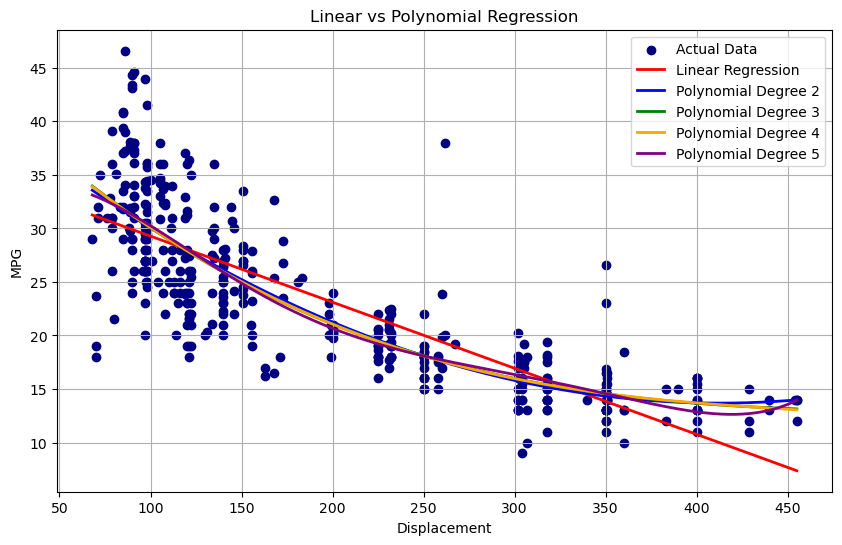

In [57]:
X_plot = pd.DataFrame({
    'displacement': np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300
    )
})

plt.figure(figsize=(10, 6))


plt.scatter(
    X['displacement'],
    y,
    color='Navy',
    label='Actual Data'
)


y_plot_linear = linear_model.predict(X_plot)

plt.plot(
    X_plot['displacement'],
    y_plot_linear,
    color='red',
    linewidth=2,
    label='Linear Regression'
)


colors = ['blue', 'green', 'orange', 'purple']

for degree, color in zip(range(2, 6), colors):

    poly, poly_model = poly_models[degree]

    X_plot_poly = poly.transform(X_plot)

    y_plot_poly = poly_model.predict(X_plot_poly)

    plt.plot(
        X_plot['displacement'],
        y_plot_poly,
        color=color,
        linewidth=2,
        label=f'Polynomial Degree {degree}'
    )

plt.xlabel('Displacement')
plt.ylabel('MPG')
plt.title('Linear vs Polynomial Regression')
plt.legend()
plt.grid(True)
plt.show()          

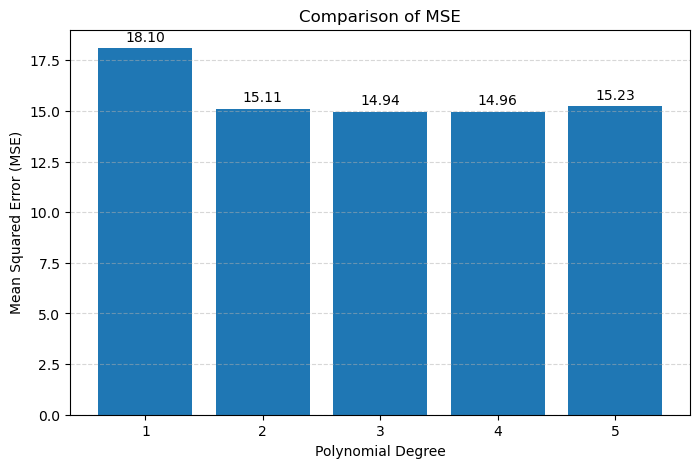

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)

plt.bar_label(bars, fmt='%.2f', padding=3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Comparison of MSE")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

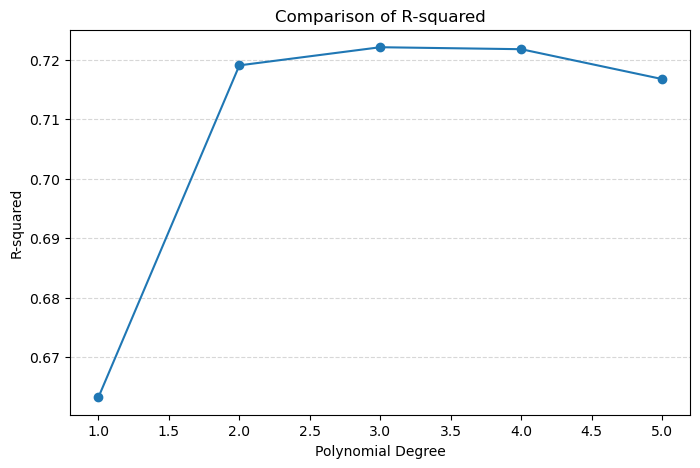

In [62]:

plt.figure(figsize=(8,5))

plt.plot(
    results_df['Degree'],
    results_df['R_squared'],
    marker='o'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("Comparison of R-squared")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()